<a href="https://colab.research.google.com/github/DanielLucero25/CSC349/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [5]:
df = pd.read_csv('cybersecurity_intrusion_data.csv')

In [6]:
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [8]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [9]:
df.columns

Index(['session_id', 'network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
session_id,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0


In [11]:
df = df.drop(columns=['session_id'])

In [12]:
df.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [14]:
df.dtypes

,0
network_packet_size,int64
protocol_type,object
login_attempts,int64
session_duration,float64
encryption_used,object
ip_reputation_score,float64
failed_logins,int64
browser_type,object
unusual_time_access,int64
attack_detected,int64


In [15]:
X = df.drop(columns=['attack_detected'])
y = df['attack_detected']

In [16]:
from pandas.core.arrays import categorical
numerical_features = [
    'network_packet_size',
    'login_attempts',
    'session_duration',
    'ip_reputation_score',
    'failed_logins',
    'unusual_time_access'
]

categorical_features = [
    'protocol_type',
    'encryption_used',
    'browser_type'
]

In [17]:
print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']
Categorical: ['protocol_type', 'encryption_used', 'browser_type']


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [20]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [21]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [22]:
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

In [23]:
preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

In [24]:
X_processed = preprocessing_pipeline.fit_transform(X)

In [25]:
X_processed.shape

(9537, 16)

In [26]:
correlation_matrix = df[numerical_features + ['attack_detected']].corr(method='pearson')

correlation_matrix

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
network_packet_size,1.000000,-0.001890,0.021650,0.002320,-0.011676,-0.001255,-0.006798
login_attempts,-0.001890,1.000000,0.006392,-0.002618,-0.013507,0.007349,0.277320
session_duration,0.021650,0.006392,1.000000,-0.005077,0.019375,0.012930,0.041602
ip_reputation_score,0.002320,-0.002618,-0.005077,1.000000,0.015613,-0.003146,0.211540
failed_logins,-0.011676,-0.013507,0.019375,0.015613,1.000000,0.006131,0.363726
unusual_time_access,-0.001255,0.007349,0.012930,-0.003146,0.006131,1.000000,0.008652
attack_detected,-0.006798,0.277320,0.041602,0.211540,0.363726,0.008652,1.000000


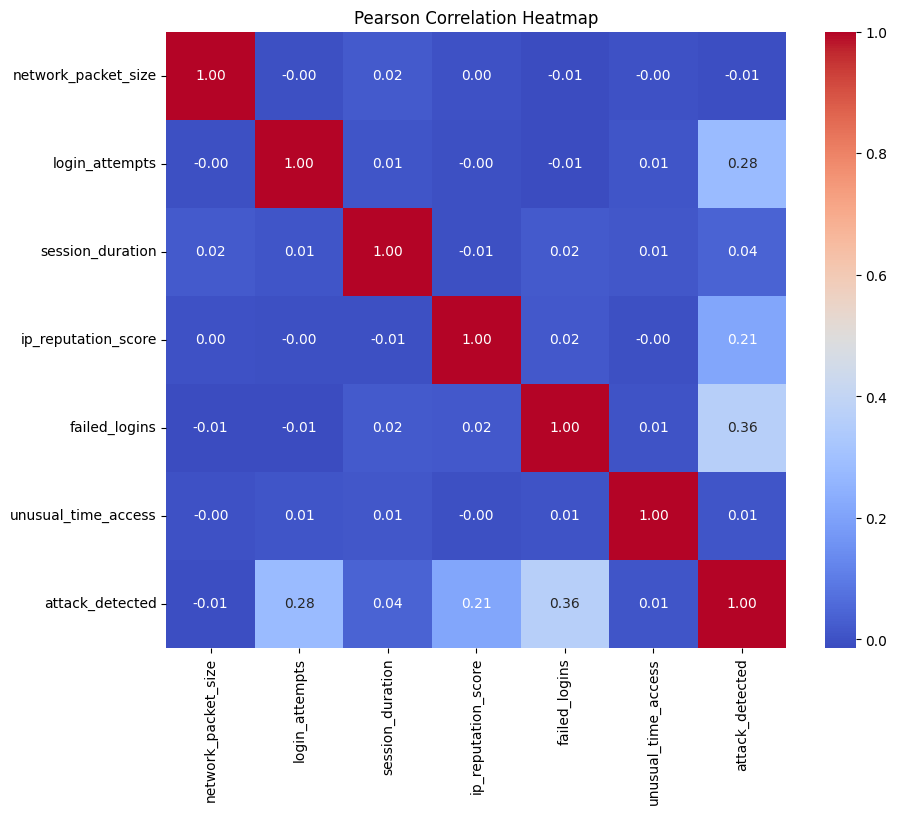

In [27]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Pearson Correlation Heatmap')
plt.show()

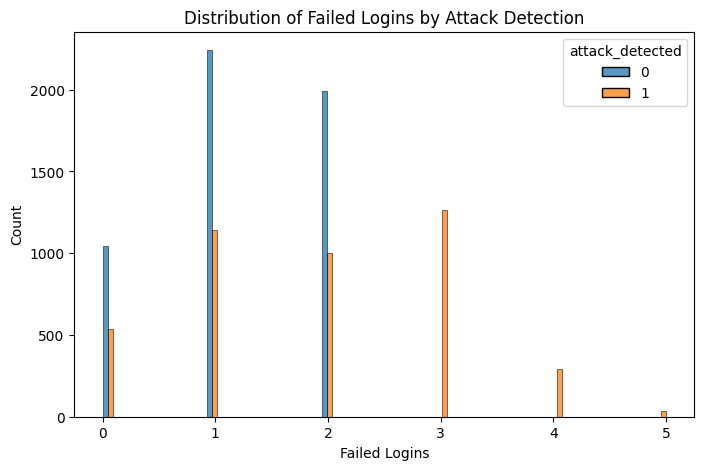

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='failed_logins',
    hue='attack_detected',
    multiple='dodge'
)

plt.title('Distribution of Failed Logins by Attack Detection')
plt.xlabel('Failed Logins')
plt.ylabel('Count')
plt.show()

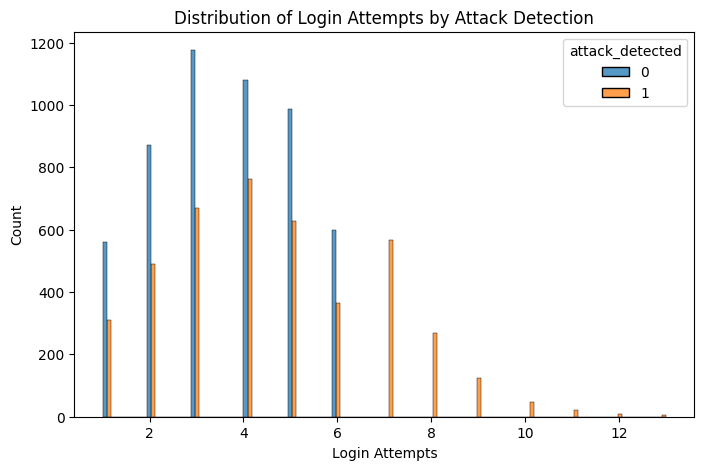

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='login_attempts',
    hue='attack_detected',
    multiple='dodge'
)

plt.title('Distribution of Login Attempts by Attack Detection')
plt.xlabel('Login Attempts')
plt.ylabel('Count')
plt.show()

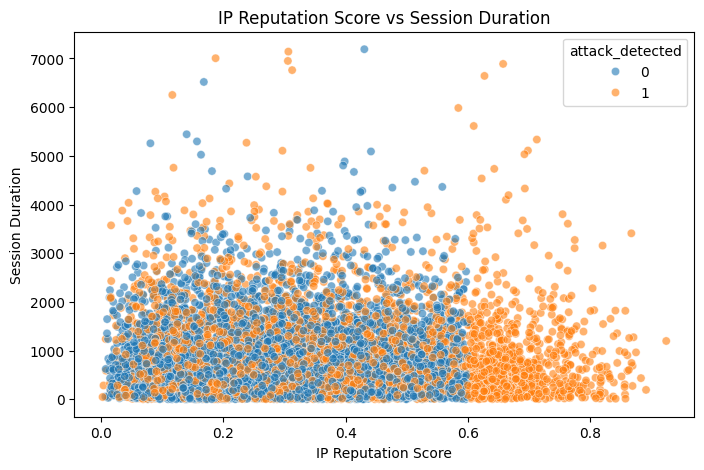

In [32]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='ip_reputation_score',
    y='session_duration',
    hue='attack_detected',
    alpha=0.6
)

plt.title('IP Reputation Score vs Session Duration')
plt.xlabel('IP Reputation Score')
plt.ylabel('Session Duration')
plt.show()

In [33]:
import numpy as np

print("Missing values after preprocessing:", np.isnan(X_processed).sum())

Missing values after preprocessing: 0
